In [11]:
import pandas as pd
import sqlite3

# Load data from database
conn = sqlite3.connect("../shipment_warehouse.db")
df = pd.read_sql("SELECT * FROM shipments", conn)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (180519, 49)

Columns:
['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 'shipping_mode', 'is_late', 'shipping_delay_days']


In [3]:
df.describe()

,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,late_delivery_risk,category_id,customer_id,customer_zipcode,department_id,latitude,...,sales,order_item_total,order_profit_per_order,order_zipcode,product_card_id,product_category_id,product_price,product_status,is_late,shipping_delay_days
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,180519.000000,180519.0,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,141.232550,0.0,0.548291,0.565807
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,139.732492,0.0,0.497664,1.490966
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,9.990000,0.0,0.000000,-2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,50.000000,0.0,0.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,59.990002,0.0,1.000000,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,199.990005,0.0,1.000000,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,1999.989990,0.0,1.000000,4.000000


In [5]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
customer_zipcode         3
order_zipcode       155679
dtype: int64


In [12]:
pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 31.8 MB/s  0:00:00 30.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 52.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]5;237m━━━━ 8/9 [seaborn]s]es]
Note: you may need to restart the kernel to use updated packages.


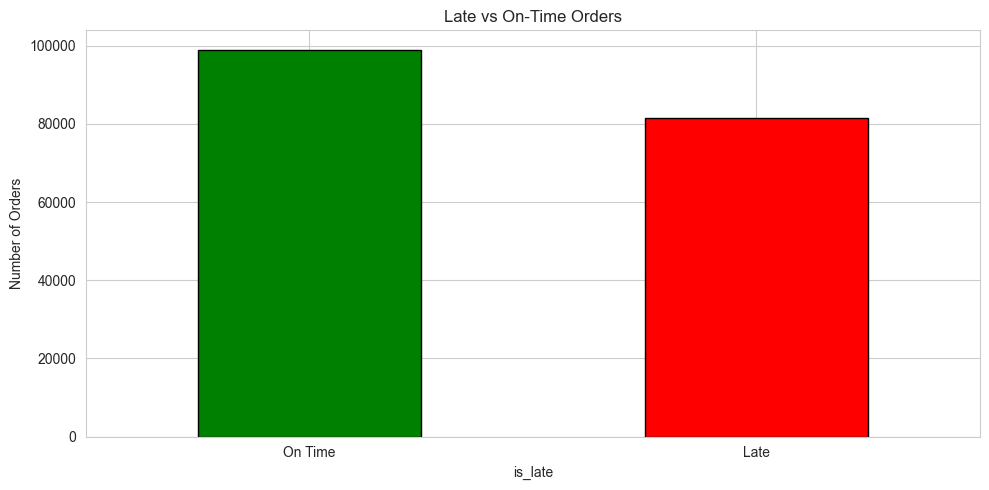

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Plot 1 — Late vs On Time orders
df['is_late'].value_counts().plot(
    kind='bar',
    color=['green', 'red'],
    edgecolor='black'
)
plt.title('Late vs On-Time Orders')
plt.xticks([0, 1], ['On Time', 'Late'], rotation=0)
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

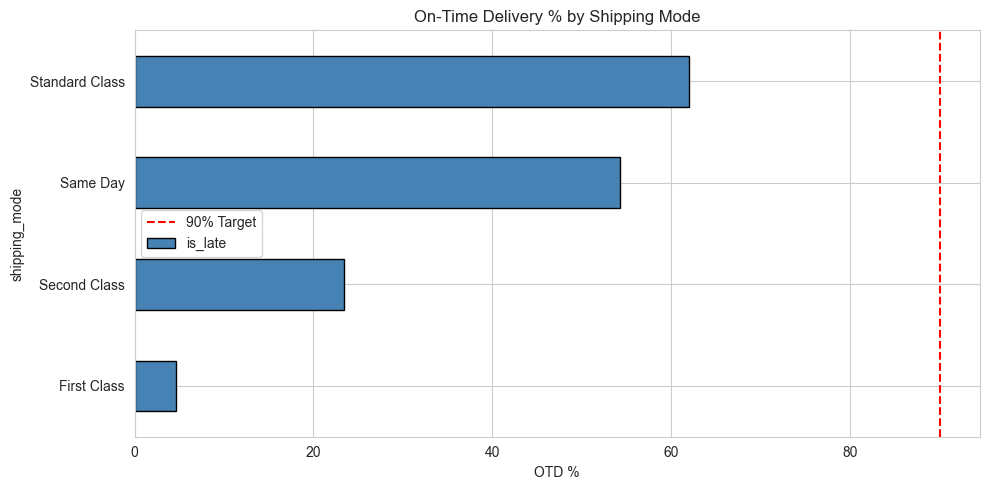

In [26]:
# Plot 2 — OTD% by Shipping Mode
otd_by_mode = df.groupby('shipping_mode')['is_late'].mean() * 100
otd_by_mode = 100 - otd_by_mode  # convert late rate to OTD%

otd_by_mode.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)
plt.title('On-Time Delivery % by Shipping Mode')
plt.xlabel('OTD %')
plt.axvline(x=90, color='red', linestyle='--', label='90% Target')
plt.legend()
plt.tight_layout()
plt.show()

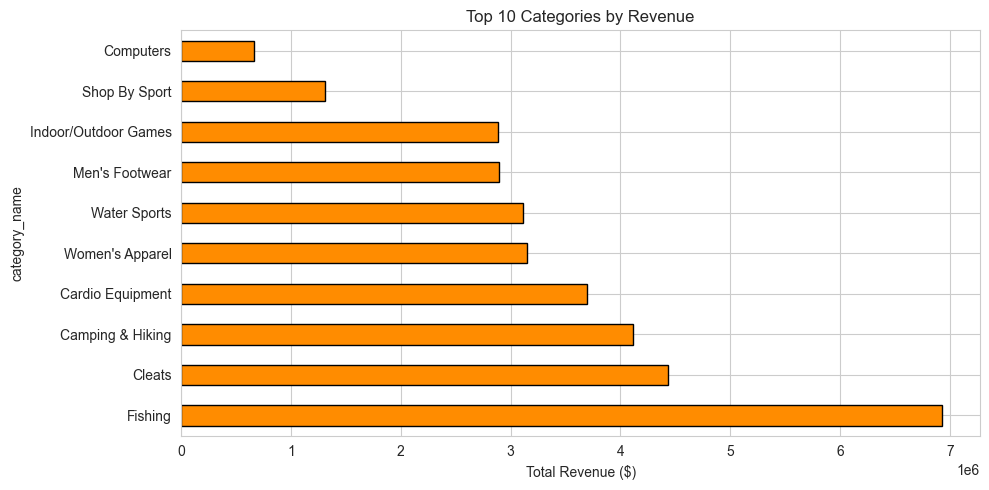

In [28]:
# Plot 3 — Top 10 Categories by Revenue
top_categories = df.groupby('category_name')['sales'].sum().sort_values(ascending=False).head(10)

top_categories.plot(
    kind='barh',
    color='darkorange',
    edgecolor='black'
)
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

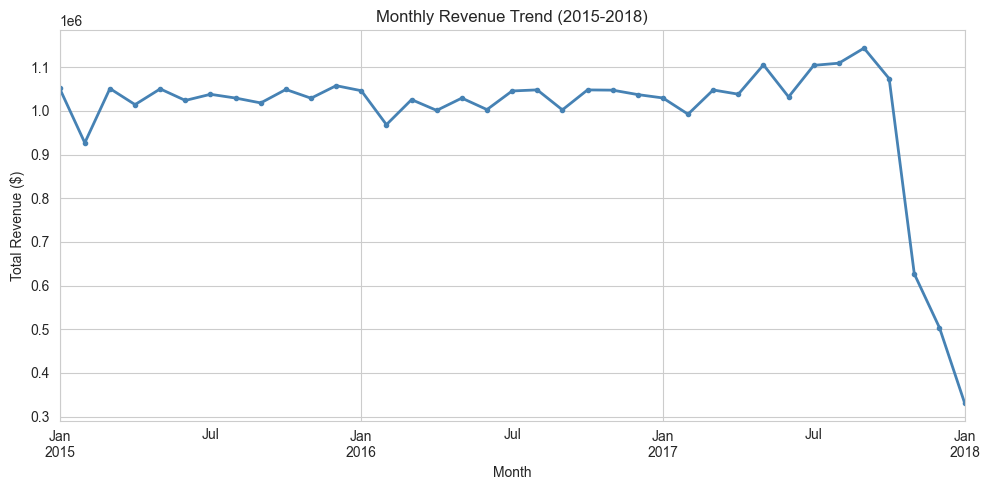

In [29]:
# Plot 4 — Monthly Revenue Trend
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
monthly_revenue = df.groupby(df['order_date_dateorders'].dt.to_period('M'))['sales'].sum()

monthly_revenue.plot(
    kind='line',
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=3
)
plt.title('Monthly Revenue Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

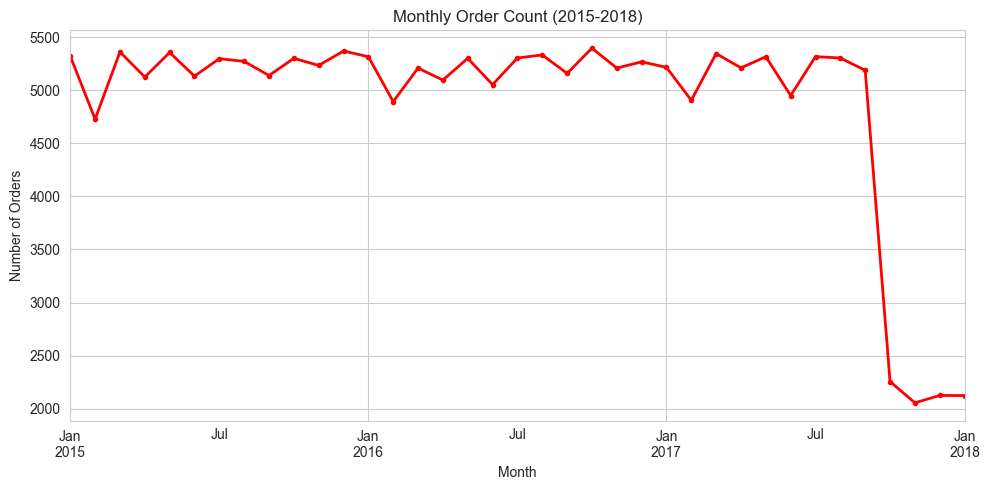


Last 6 months order count:
order_date_dateorders
2017-08    5305
2017-09    5189
2017-10    2255
2017-11    2055
2017-12    2124
2018-01    2123
Freq: M, Name: order_id, dtype: int64


In [34]:
# Verify the drop — check order count by month
monthly_orders = df.groupby(df['order_date_dateorders'].dt.to_period('M'))['order_id'].count()

monthly_orders.plot(
    kind='line',
    color='red',
    linewidth=2,
    marker='o',
    markersize=3
)
plt.title('Monthly Order Count (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# Print the last 6 months
print("\nLast 6 months order count:")
print(monthly_orders.tail(6))

/var/folders/cw/g7py2tq50pl10z5dg9pp0lkr0000gn/T/ipykernel_37781/522832210.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dept_margin = df.groupby('department_name').apply(


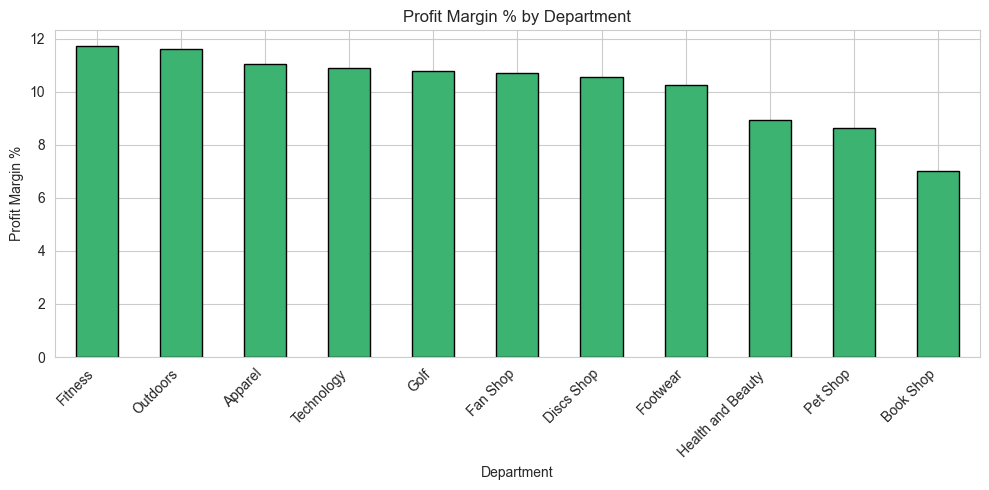

In [35]:
# Plot 5 — Profit Margin by Department
dept_margin = df.groupby('department_name').apply(
    lambda x: (x['order_profit_per_order'].sum() / x['sales'].sum()) * 100
).sort_values(ascending=False)

dept_margin.plot(
    kind='bar',
    color='mediumseagreen',
    edgecolor='black'
)
plt.title('Profit Margin % by Department')
plt.xlabel('Department')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

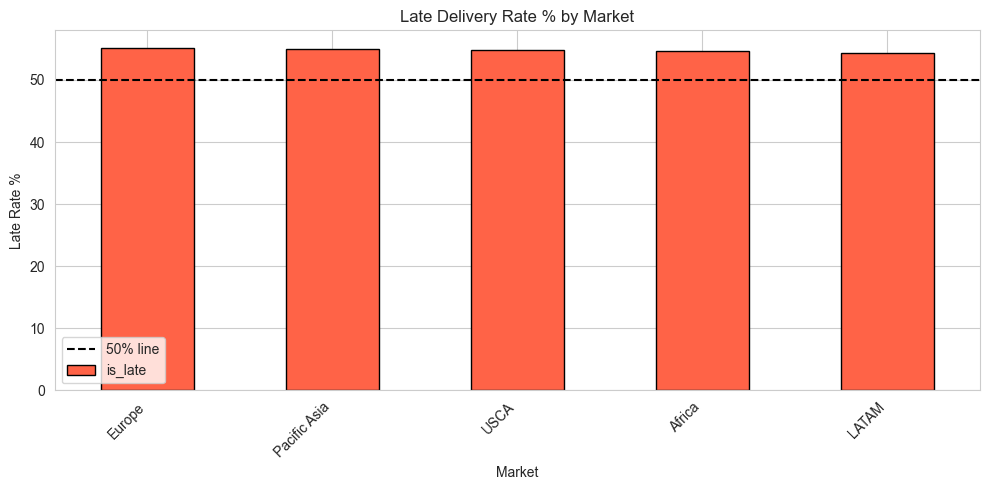

In [36]:
# Plot 6 — Late Delivery Rate by Market
late_by_market = df.groupby('market')['is_late'].mean() * 100

late_by_market.sort_values(ascending=False).plot(
    kind='bar',
    color='tomato',
    edgecolor='black'
)
plt.title('Late Delivery Rate % by Market')
plt.xlabel('Market')
plt.ylabel('Late Rate %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=50, color='black', linestyle='--', label='50% line')
plt.legend()
plt.tight_layout()
plt.show()

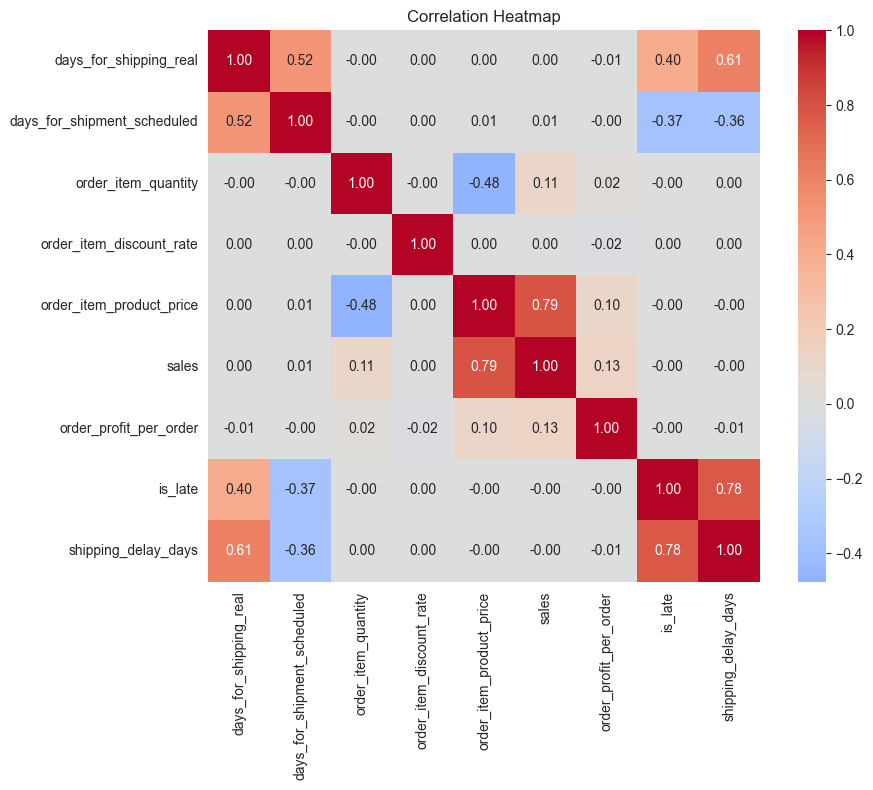

In [37]:
# Plot 7 — Correlation Heatmap
numeric_cols = [
    'days_for_shipping_real',
    'days_for_shipment_scheduled',
    'order_item_quantity',
    'order_item_discount_rate',
    'order_item_product_price',
    'sales',
    'order_profit_per_order',
    'is_late',
    'shipping_delay_days'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [38]:
git add notebooks/01_eda.ipynb
git commit -m "add EDA notebook — 7 charts covering OTD, revenue, correlation analysis"
git push

SyntaxError: invalid syntax (2499120821.py, line 1)